Begining Training. 15 Epochs. 31 Batches. Model Params: 607820


100%|██████████| 15/15 [00:52<00:00,  3.48s/it, Epoch: 14, Batch Loss: 0.12, Improvement: 0.00, Min Loss: 0.11394255992866331, Batches:31] 


<Axes: >

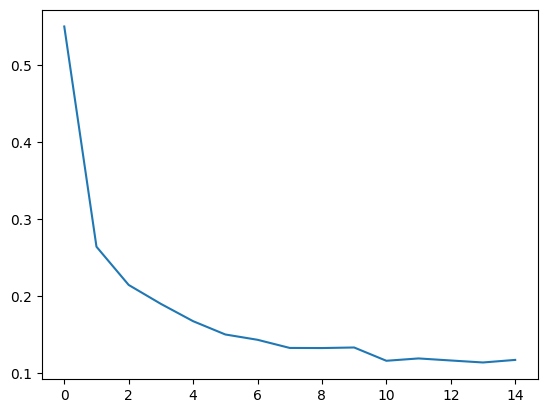

In [ ]:
from climb_conversion import ClimbsFeatureArray
from unet_diffusion import ResidualBlock1D, SinusoidalPositionEmbeddings
from diffusion_utils import test_single_batch, moving_average, clear_compile_keys
import torch
from torch import nn
from torch import Tensor
from pathlib import Path
import torch.nn.functional as F
import torch
from torch import nn, Tensor
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import sqlite3
from torchinfo import summary
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import pandas as pd
import seaborn as sns

torch.set_printoptions(linewidth=300)

class Noiser(nn.Module):
    """Noiser class with concatenation U-Net architecture, learnable null embeddings, and zero-COM input projection."""
    def __init__(self, hidden_dim=256, layers = 3, in_feature_dim = 12, out_feature_dim = 12, cond_dim = 4, sinusoidal = True):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.time_mlp = nn.Sequential(
            (SinusoidalPositionEmbeddings(hidden_dim) if sinusoidal else nn.Linear(1,hidden_dim)),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim)
        )

        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.null_cond_emb = nn.Parameter(torch.randn(1, hidden_dim, device=self.device))

        self.combine_t_mlp = nn.Sequential(
            nn.Linear(hidden_dim*2,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.init_conv = ResidualBlock1D(in_feature_dim, hidden_dim, hidden_dim)

        self.down_blocks = nn.ModuleList([ResidualBlock1D(hidden_dim*(i+1), hidden_dim*(i+2), hidden_dim) for i in range(layers)])

        # Residuals for up blocks
        self.up_blocks = nn.ModuleList([ResidualBlock1D(hidden_dim*(i+1), hidden_dim*(i), hidden_dim) for i in range(layers,0,-1)])
        self.head = nn.Conv1d(hidden_dim, out_feature_dim, 1)
    
    def forward(self, climbs: Tensor, cond: Tensor | None, t: Tensor)-> Tensor:
        """
        Run denoising pass. Predicts the added noise from the noisy data.
        
        :param climbs: Tensor with hold-set features, including conditional features and hold roles. [B, S, H]
        :param cond: Tensor with climb conditional variables. [B, 4]
        :param t: Tensor with timestep of diffusion. [B, 1]
        :returns: Tensor, the predicted noise added after timestep t.
        """
        (B, S, H) = climbs.shape
        emb_t = self.time_mlp(t)
        
        if cond is not None: 
            emb_c = self.cond_mlp(cond)
        else:
            emb_c = self.null_cond_emb.repeat(B, 1)
        
        emb_c = self.combine_t_mlp(torch.cat([emb_t, emb_c], dim=1))
        emb_h = self.init_conv(climbs.transpose(1,2), emb_c)
        
        skip_conns = []
        for layer in self.down_blocks:
            skip_conns.append(emb_h)
            emb_h = layer(emb_h, emb_c)
                
        for layer in self.up_blocks:
            skip_conn = skip_conns.pop()
            emb_h = skip_conn + layer(emb_h, emb_c)
        
        result = self.head(emb_h).transpose(1,2)

        return result

#-----------------------------------------------------------------------
# DDPM MODEL
#-----------------------------------------------------------------------
class ClimbDDPM(nn.Module):
    def __init__(self, model: nn.Module, weights_path: Path | str | None = None):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = model
        if weights_path:
            self.load_state_dict(clear_compile_keys(weights_path))
    
    def _cos_alpha_bar(self, t: Tensor)-> Tensor:
        t = t.view(-1,1,1)
        epsilon = 0.0004
        return  torch.cos((t+epsilon)/(1+2*epsilon)*torch.pi/2)**2
    
    def _composite_alpha_bar(self, t: Tensor, n_features: int) -> Tensor:
        """Get a composite alpha schedule which preserves the last feature column (the "is_null" flag) until t=0.8.
        This allows the Climb DDPM Generator to perform projection on only non-null holds, beginning at t=0.8"""
        
        a_features = self._cos_alpha_bar(t)
        a_null = self._cos_alpha_bar(torch.clamp((t-0.8) / 0.2, 0.0, 1.0))

        a_full = a_features.expand(-1, -1, n_features-1)
        
        return torch.cat([a_full,a_null],dim=2)
    
    def loss(self, sample_climbs: Tensor, cond: Tensor | None):
        """Perform a diffusion Training step and return the loss resulting from the model in the training run.
        Currently returns tuple (loss, real_hold_loss, null_hold_loss)"""
        B, S, H = sample_climbs.shape
        
        t = torch.round(torch.rand(B, 1, device=self.device), decimals=2)
        noise = torch.randn((B, S, H), device = self.device)

        # Don't add noise to the is_null flag when t <= 0.8, as the a value for is_null is 0 (this guarantees that the true value of is_null is known by t=0.8)
        null_mask = (t > 0.8).float()

        noise[:,:,-1] *= null_mask
        print(torch.round(noise,decimals=2))
        noisy = self.forward_diffusion(sample_climbs, t, noise)
        pred_noise = self.model(noisy, cond, t)
        
        return F.mse_loss(pred_noise, noise)
        
    def predict_clean(self, noisy, cond, t, epsilon=.0004):
        """Return predicted clean data."""
        (B, S, H) = noisy.shape
        a = self._composite_alpha_bar(t, H)
        # print(torch.round(a,decimals=2))
        prediction = self.model(noisy, cond, t)
        clean = (noisy - torch.sqrt(1-a)*prediction)/(torch.sqrt(a)+epsilon)
        return clean
    
    def predict_cfg(self, noisy, cond, t, guidance_value=1.0, epsilon=.0004):
        (B, S, H) = noisy.shape
        a = self._composite_alpha_bar(t, H)
        cf_pred = self.model(noisy, None, t)
        pred = self.model(noisy, cond, t)
        cfg = cf_pred+(pred-cf_pred)*guidance_value
        clean = (noisy - torch.sqrt(1-a)*cfg)/(torch.sqrt(a)+epsilon)
        return clean
    
    def forward_diffusion(self, clean: Tensor, t: Tensor, noise: Tensor)-> Tensor:
        """Perform forward diffusion to add noise to clean data based on noise adding schedule."""
        (B, S, H) = clean.shape

        a = self._composite_alpha_bar(t, H)
        # print(torch.round(a,decimals=2))
        return torch.sqrt(a) * clean + torch.sqrt(1-a) * noise
    
    def forward(self, noisy, cond, t):
        return self.predict_clean(noisy, cond, t)
    

class DDPMTrainer():
    def __init__(
        self,
        model: nn.Module,
        dataset: TensorDataset | None = None,
        default_batch_size: int = 64,
        lr: float = 1e-3
    ):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.dataset = dataset
        self.default_batch_size = default_batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.1)
    
    def train(
        self,
        epochs: int,
        save_path: str | None = None,
        batch_size: int | None = None,
        num_workers: int | None = None,
        dataset: TensorDataset | None = None,
        save_on_best: bool = False,
        clip_grad_norm: bool = True,
    )-> tuple[nn.Module, list]:
        """
        Train a model (probably of type ClimbDDPM) on the dataset contained in the trainer. (If dataset is provided, train on that dataset instead)

        :param epochs: Number of training epochs
        :type epochs: int
        :param save_path: Model weights save-path
        :type save_path: str
        :param batch_size: Training batch size
        :type batch_size: int | None
        :param num_workers: Number of workers
        :type num_workers: int | None
        :param dataset: Training Dataset; defaults to model.dataset
        :type dataset: TensorDataset | None
        :param save_on_best: boolean indicating whether to save model weights every time a minimum loss is reached.
        :type save_on_best: bool
        :return: Tuple of (best_model: nn.Module, training_data: np.array)
        :rtype: tuple[Module, Any]
        """
        if dataset is None:
            dataset = self.dataset
        if dataset is None:
            raise ValueError("Dataset is None. Cannot train on no dataset")
        if batch_size is None:
            batch_size = self.default_batch_size
        if num_workers is None:
            num_workers = 0

        batches = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
        losses = []
        print(f"Begining Training. {epochs} Epochs. {len(batches)} Batches. Model Params: {sum([p.numel() for p in self.model.parameters()])}")

        with tqdm(range(epochs)) as pbar:
            pbar.set_postfix_str(f"Epoch: {0}, Batches:{len(batches)}")
            for epoch in pbar:
                total_loss = 0
                for x, c in batches:
                    x, c = x.to(self.device), c.to(self.device)

                    self.optimizer.zero_grad()
                    loss = self.model.loss(x, c) + self.model.loss(x, None) * 0.25
                    if clip_grad_norm:
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    
                    loss.backward()
                    self.optimizer.step()

                    raise Exception

                    total_loss+=loss.item()
                total_loss /= len(batches)
                improvement = (total_loss - losses[-1]) if len(losses) > 0 else 0
                pbar.set_postfix_str(f"Epoch: {epoch}, Batch Loss: {total_loss:.2f}, Improvement: {improvement:.2f}, Min Loss: {min(losses) if len(losses) > 0 else 0}, Batches:{len(batches)}")
                losses.append(total_loss)

                if save_on_best and total_loss < min(losses) and len(losses) % 2 == 0:
                    torch.save(self.model.state_dict(), save_path)
            self.scheduler.step()
        if save_path is not None:
            torch.save(self.model.state_dict(), save_path)
        return self.model, losses


# cfa = ClimbsFeatureArray()
# climbs = cfa.get_features(limit=1000)
ddpm = ClimbDDPM(Noiser(64, 2, sinusoidal=True))
trainer = DDPMTrainer(ddpm, climbs)
model, losses = trainer.train(15, save_path = "data/weights/new_unet_diff.pth")
sns.lineplot(y=losses, x=list(range(15)))